In [2]:
# import requests
# import pandas as pd

# # -------------------------------
# # Location: San Diego, California
# # -------------------------------
# LATITUDE = 32.7157
# LONGITUDE = -117.1611

# # -------------------------------
# # Open-Meteo API URL
# # -------------------------------
# url = "https://api.open-meteo.com/v1/forecast"

# # -------------------------------
# # Parameters
# # -------------------------------
# params = {
#     "latitude": LATITUDE,
#     "longitude": LONGITUDE,

#     # Hourly weather variables
#     "hourly": [
#         "temperature_2m",
#         "relative_humidity_2m",
#         "cloud_cover",
#         "pressure_msl",
#         "wind_speed_10m",
#         "precipitation"
#     ],

#     # Forecast duration
#     "forecast_days": 7,

#     # Timezone
#     "timezone": "auto"
# }

# # -------------------------------
# # Send API Request
# # -------------------------------
# response = requests.get(url, params=params)

# # Convert response to JSON
# data = response.json()

# # -------------------------------
# # Extract Hourly Data
# # -------------------------------
# hourly_data = data["hourly"]

# # -------------------------------
# # Convert to Pandas DataFrame
# # -------------------------------
# df = pd.DataFrame({
#     "time": hourly_data["time"],
#     "temperature_2m": hourly_data["temperature_2m"],
#     "relative_humidity_2m": hourly_data["relative_humidity_2m"],
#     "cloud_cover": hourly_data["cloud_cover"],
#     "pressure_msl": hourly_data["pressure_msl"],
#     "wind_speed_10m": hourly_data["wind_speed_10m"],
#     "precipitation": hourly_data["precipitation"]
# })

# # -------------------------------
# # Display First Rows
# # -------------------------------
# print(df.head())

# # -------------------------------
# # Save to CSV (Optional)
# # -------------------------------
# df.to_csv("san_diego_weather_data.csv", index=False)

# print("\nWeather data saved successfully!")

In [3]:
# import requests
# import pandas as pd

# LATITUDE = 32.7157
# LONGITUDE = -117.1611

# url = "https://archive-api.open-meteo.com/v1/archive"

# params = {
#     "latitude": LATITUDE,
#     "longitude": LONGITUDE,

#     "start_time": "2016-01-01",
#     "end_time": "2025-12-31",

#     "hourly": [
#         "temperature_2m",
#         "relative_humidity_2m",
#         "cloud_cover",
#         "pressure_msl",
#         "wind_speed_10m",
#         "precipitation"
#     ],

#     "timezone": "auto"
# }

# response = requests.get(url, params=params)
# data = response.json()

# hourly = data["hourly"]

# df = pd.DataFrame({
#     "time": hourly["time"],
#     "temperature_2m": hourly["temperature_2m"],
#     "relative_humidity_2m": hourly["relative_humidity_2m"],
#     "cloud_cover": hourly["cloud_cover"],
#     "pressure_msl": hourly["pressure_msl"],
#     "wind_speed_10m": hourly["wind_speed_10m"],
#     "precipitation": hourly["precipitation"]
# })

# print(df.head())
# print(df.shape)

# df.to_csv("san_diego_10_year_weather.csv", index=False)

# print("Saved successfully!")

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
rain_data=pd.read_csv(r"C:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\san_diego_10_year_weather.csv",parse_dates=['time'])

In [4]:
rain_data.head()

,time,temperature_2m,relative_humidity_2m,cloud_cover,pressure_msl,wind_speed_10m,precipitation
0,2016-01-01 00:00:00,7.9,74,0,1018.1,11.3,0.0
1,2016-01-01 01:00:00,7.5,73,0,1017.7,11.9,0.0
2,2016-01-01 02:00:00,7.1,75,0,1017.5,12.2,0.0
3,2016-01-01 03:00:00,6.8,75,0,1017.7,13.7,0.0
4,2016-01-01 04:00:00,6.6,76,0,1017.5,12.6,0.0


In [ ]:
pd.infer_freq(rain_data['time'])

'h'

: 

In [7]:
rain_data['Rain_Category']=pd.cut(rain_data['precipitation'],bins=[-0.1,0,100],labels=['No Rain','Rain'])

In [8]:
rain_data['Day_of_Year']=rain_data['time'].dt.dayofyear
rain_data['Month']=rain_data['time'].dt.month
rain_data['Year']=rain_data['time'].dt.year

In [9]:
rain_data.head()

,time,temperature_2m,relative_humidity_2m,cloud_cover,pressure_msl,wind_speed_10m,precipitation,Rain_Category,Day_of_Year,Month,Year
0,2016-01-01 00:00:00,7.9,74,0,1018.1,11.3,0.0,No Rain,1,1,2016
1,2016-01-01 01:00:00,7.5,73,0,1017.7,11.9,0.0,No Rain,1,1,2016
2,2016-01-01 02:00:00,7.1,75,0,1017.5,12.2,0.0,No Rain,1,1,2016
3,2016-01-01 03:00:00,6.8,75,0,1017.7,13.7,0.0,No Rain,1,1,2016
4,2016-01-01 04:00:00,6.6,76,0,1017.5,12.6,0.0,No Rain,1,1,2016


In [10]:
rain_data['Rain_Category'].value_counts()

Rain_Category
No Rain    82291
Rain        5381
Name: count, dtype: int64

In [11]:
rain_data[rain_data['Rain_Category'].isna()]

,time,temperature_2m,relative_humidity_2m,cloud_cover,pressure_msl,wind_speed_10m,precipitation,Rain_Category,Day_of_Year,Month,Year


<Axes: ylabel='precipitation'>

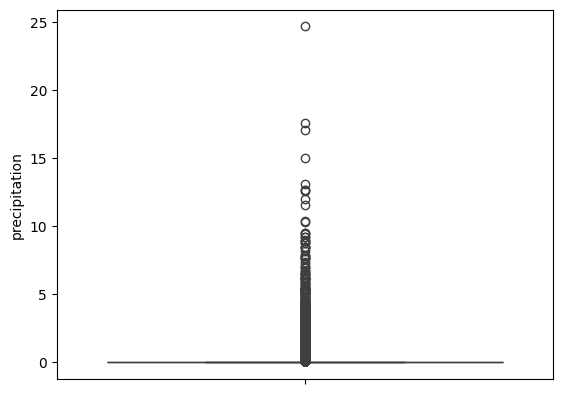

In [12]:
sns.boxplot(rain_data['precipitation'])

In [ ]:
rain_data=rain_data.drop(columns=['time','precipitation','Rain_Category','Year'])
target=rain_data['Rain_Category']

In [ ]:
scalar=StandardScaler()
rain_data_scaled=pd.DataFrame(scalar.fit_transform(rain_data),columns=rain_data.columns)
rain_data_scaled.head()

,temperature_2m,relative_humidity_2m,cloud_cover,pressure_msl,wind_speed_10m,Day_of_Year,Month
0,-1.988296,0.015099,-1.021718,0.777776,0.310924,-1.72731,-1.601193
1,-2.075651,-0.040989,-1.021718,0.667330,0.418303,-1.72731,-1.601193
2,-2.163006,0.071186,-1.021718,0.612107,0.471993,-1.72731,-1.601193
3,-2.228522,0.071186,-1.021718,0.667330,0.740441,-1.72731,-1.601193
4,-2.272199,0.127273,-1.021718,0.612107,0.543579,-1.72731,-1.601193


In [ ]:
model=LogisticRegression(class_weight='balanced',max_iter=1000)
X_train,X_test,y_train,y_test=train_test_split(rain_data_scaled,target,test_size=0.2,random_state=100)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [16]:
predictions=model.predict(X_test)
print(classification_report(y_test,predictions))
print(confusion_matrix(y_test,predictions))

              precision    recall  f1-score   support

     No Rain       0.99      0.78      0.87     16469
        Rain       0.19      0.83      0.32      1066

    accuracy                           0.78     17535
   macro avg       0.59      0.80      0.59     17535
weighted avg       0.94      0.78      0.84     17535

[[12836  3633]
 [  186   880]]


In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
RandomForest=RandomForestClassifier(class_weight='balanced',n_estimators=100,random_state=100)
RandomForest.fit(X_train,y_train)
rf_predictions=RandomForest.predict(X_test)
print(classification_report(y_test,rf_predictions))

              precision    recall  f1-score   support

     No Rain       0.96      0.99      0.98     16469
        Rain       0.81      0.42      0.55      1066

    accuracy                           0.96     17535
   macro avg       0.89      0.71      0.76     17535
weighted avg       0.95      0.96      0.95     17535



In [ ]:
im =RandomForest.feature_importances_
feature_importance_df = pd.DataFrame(
    {'Importance': RandomForest.feature_importances_},
    index=rain_data.columns
)
feature_importance_df.sort_values(by='Importance',ascending=False)


,Importance
cloud_cover,0.283604
wind_speed_10m,0.163497
temperature_2m,0.160066
relative_humidity_2m,0.126067
Day_of_Year,0.120492
pressure_msl,0.100102
Month,0.046172


In [20]:
import xgboost as xgb

In [21]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [22]:
rain_data['Rain_Category']=label_encoder.fit_transform(rain_data['Rain_Category'])

In [ ]:
rain_data = rain_data.drop(columns=['time','precipitation', 'Rain_Category'])
targets = rain_data['Rain_Category']

In [24]:
targets

0        0
1        0
2        0
3        0
4        0
        ..
87667    1
87668    0
87669    0
87670    0
87671    1
Name: Rain_Category, Length: 87672, dtype: int64

In [ ]:
rain_data

,temperature_2m,relative_humidity_2m,cloud_cover,pressure_msl,wind_speed_10m,Day_of_Year,Month,Year
0,7.9,74,0,1018.1,11.3,1,1,2016
1,7.5,73,0,1017.7,11.9,1,1,2016
2,7.1,75,0,1017.5,12.2,1,1,2016
3,6.8,75,0,1017.7,13.7,1,1,2016
4,6.6,76,0,1017.5,12.6,1,1,2016
...,...,...,...,...,...,...,...,...
87667,15.2,97,100,1015.3,2.8,365,12,2025
87668,15.3,93,100,1015.0,8.3,365,12,2025
87669,15.6,90,100,1015.2,6.9,365,12,2025
87670,15.6,91,100,1015.9,2.1,365,12,2025


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(rain_data,targets,test_size=0.2,random_state=100)

In [27]:
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', use_label_encoder=False, random_state=100)
xgb_model.fit(X_train, y_train)

c:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:10:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [28]:
xgb_predictions = xgb_model.predict(X_test)
print(classification_report(y_test, xgb_predictions))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     16469
           1       0.74      0.51      0.61      1066

    accuracy                           0.96     17535
   macro avg       0.86      0.75      0.79     17535
weighted avg       0.96      0.96      0.96     17535



In [29]:
from imblearn.over_sampling import SMOTE

In [30]:
smote = SMOTE(random_state=100)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [31]:
print(y_train.value_counts())
print(y_train_resampled.value_counts())

Rain_Category
0    65822
1     4315
Name: count, dtype: int64
Rain_Category
0    65822
1    65822
Name: count, dtype: int64


In [32]:
X_test.head()

,temperature_2m,relative_humidity_2m,cloud_cover,pressure_msl,wind_speed_10m,Day_of_Year,Month,Year
29962,17.2,69,100,1012.7,6.1,153,6,2019
623,9.8,86,1,1023.3,7.3,26,1,2016
38444,17.0,84,0,1015.3,11.5,141,5,2020
63736,16.4,76,1,1017.8,16.1,99,4,2023
57049,18.0,83,7,1014.3,1.9,186,7,2022


In [33]:
y_test.head()

29962    0
623      0
38444    0
63736    0
57049    0
Name: Rain_Category, dtype: int64

In [34]:
X_test.head()

,temperature_2m,relative_humidity_2m,cloud_cover,pressure_msl,wind_speed_10m,Day_of_Year,Month,Year
29962,17.2,69,100,1012.7,6.1,153,6,2019
623,9.8,86,1,1023.3,7.3,26,1,2016
38444,17.0,84,0,1015.3,11.5,141,5,2020
63736,16.4,76,1,1017.8,16.1,99,4,2023
57049,18.0,83,7,1014.3,1.9,186,7,2022


In [35]:
X_train_resampled.head()

,temperature_2m,relative_humidity_2m,cloud_cover,pressure_msl,wind_speed_10m,Day_of_Year,Month,Year
0,23.7,23,2,1016.6,0.8,313,11,2019
1,14.6,98,6,1015.3,5.7,288,10,2018
2,17.8,95,17,1015.0,3.8,191,7,2016
3,14.4,82,100,1016.7,3.6,128,5,2019
4,14.2,91,81,1017.8,22.4,21,1,2019


In [36]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=100)
xgb_model.fit(X_train_resampled, y_train_resampled)

xgb_predictions_resampled = xgb_model.predict(X_test)
print(classification_report(y_test, xgb_predictions_resampled))

c:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:10:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.99      0.92      0.95     16469
           1       0.40      0.83      0.54      1066

    accuracy                           0.91     17535
   macro avg       0.69      0.88      0.75     17535
weighted avg       0.95      0.91      0.93     17535



In [37]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [38]:
y_prob

array([2.5348803e-01, 6.2857171e-06, 7.3590485e-04, ..., 9.9230099e-01,
       1.4734931e-01, 1.0217077e-03], shape=(17535,), dtype=float32)

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = []

for threshold in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:

    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(results)

print(threshold_df)

   Threshold  Precision    Recall        F1
0        0.1   0.198097  0.976548  0.329378
1        0.2   0.250246  0.955910  0.396652
2        0.3   0.296007  0.924953  0.448488
3        0.4   0.349053  0.881801  0.500133
4        0.5   0.401725  0.830206  0.541450
5        0.6   0.463719  0.767355  0.578092
6        0.7   0.538295  0.698874  0.608163
7        0.8   0.639476  0.595685  0.616804
8        0.9   0.770723  0.409944  0.535211


In [ ]:
rain_data_importance_df = pd.DataFrame(
    {'Feature': rain_data.columns, 'Importance': xgb_model.feature_importances_})
rain_data_importance_df.sort_values(by='Importance', ascending=False)

,Feature,Importance
2,cloud_cover,0.454541
6,Month,0.116432
4,wind_speed_10m,0.109781
0,temperature_2m,0.097651
1,relative_humidity_2m,0.076531
3,pressure_msl,0.055303
5,Day_of_Year,0.051772
7,Year,0.037987


In [45]:
rain_data['temperature_2m_lag_1'] = rain_data['temperature_2m'].shift(1)
rain_data['relative_humidity_2m_lag_1'] = rain_data['relative_humidity_2m'].shift(1)
rain_data['cloud_cover_lag_1'] = rain_data['cloud_cover'].shift(1)
rain_data['temperature_2m_lag_3'] = rain_data['temperature_2m'].shift(3)
rain_data['relative_humidity_2m_lag_3'] = rain_data['relative_humidity_2m'].shift(3)
rain_data['cloud_cover_lag_3'] = rain_data['cloud_cover'].shift(3)
rain_data['temperature_2m_lag_6'] = rain_data['temperature_2m'].shift(6)
rain_data['relative_humidity_2m_lag_6'] = rain_data['relative_humidity_2m'].shift(6)
rain_data['cloud_cover_lag_6'] = rain_data['cloud_cover'].shift(6)

In [46]:
rain_data


,time,temperature_2m,relative_humidity_2m,cloud_cover,pressure_msl,wind_speed_10m,precipitation,Rain_Category,Day_of_Year,Month,Year,temperature_2m_lag_1,relative_humidity_2m_lag_1,cloud_cover_lag_1,temperature_2m_lag_3,relative_humidity_2m_lag_3,cloud_cover_lag_3,temperature_2m_lag_6,relative_humidity_2m_lag_6,cloud_cover_lag_6
0,2016-01-01 00:00:00,7.9,74,0,1018.1,11.3,0.0,0,1,1,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-01 01:00:00,7.5,73,0,1017.7,11.9,0.0,0,1,1,2016,7.9,74.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-01 02:00:00,7.1,75,0,1017.5,12.2,0.0,0,1,1,2016,7.5,73.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-01 03:00:00,6.8,75,0,1017.7,13.7,0.0,0,1,1,2016,7.1,75.0,0.0,7.9,74.0,0.0,NaN,NaN,NaN
4,2016-01-01 04:00:00,6.6,76,0,1017.5,12.6,0.0,0,1,1,2016,6.8,75.0,0.0,7.5,73.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87667,2025-12-31 19:00:00,15.2,97,100,1015.3,2.8,0.7,1,365,12,2025,15.2,97.0,100.0,16.4,94.0,100.0,16.6,92.0,100.0
87668,2025-12-31 20:00:00,15.3,93,100,1015.0,8.3,0.0,0,365,12,2025,15.2,97.0,100.0,15.2,96.0,100.0,16.8,96.0,100.0
87669,2025-12-31 21:00:00,15.6,90,100,1015.2,6.9,0.0,0,365,12,2025,15.3,93.0,100.0,15.2,97.0,100.0,16.6,96.0,100.0
87670,2025-12-31 22:00:00,15.6,91,100,1015.9,2.1,0.0,0,365,12,2025,15.6,90.0,100.0,15.2,97.0,100.0,16.4,94.0,100.0


In [47]:
rain_data.dropna(inplace=True)

In [48]:
rain_data

,time,temperature_2m,relative_humidity_2m,cloud_cover,pressure_msl,wind_speed_10m,precipitation,Rain_Category,Day_of_Year,Month,Year,temperature_2m_lag_1,relative_humidity_2m_lag_1,cloud_cover_lag_1,temperature_2m_lag_3,relative_humidity_2m_lag_3,cloud_cover_lag_3,temperature_2m_lag_6,relative_humidity_2m_lag_6,cloud_cover_lag_6
6,2016-01-01 06:00:00,6.2,78,0,1017.7,13.6,0.0,0,1,1,2016,6.3,77.0,0.0,6.8,75.0,0.0,7.9,74.0,0.0
7,2016-01-01 07:00:00,6.1,78,0,1018.2,13.6,0.0,0,1,1,2016,6.2,78.0,0.0,6.6,76.0,0.0,7.5,73.0,0.0
8,2016-01-01 08:00:00,6.0,78,9,1019.1,13.6,0.0,0,1,1,2016,6.1,78.0,0.0,6.3,77.0,0.0,7.1,75.0,0.0
9,2016-01-01 09:00:00,7.2,73,12,1019.6,15.5,0.0,0,1,1,2016,6.0,78.0,9.0,6.2,78.0,0.0,6.8,75.0,0.0
10,2016-01-01 10:00:00,11.2,56,0,1020.0,12.0,0.0,0,1,1,2016,7.2,73.0,12.0,6.1,78.0,0.0,6.6,76.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87667,2025-12-31 19:00:00,15.2,97,100,1015.3,2.8,0.7,1,365,12,2025,15.2,97.0,100.0,16.4,94.0,100.0,16.6,92.0,100.0
87668,2025-12-31 20:00:00,15.3,93,100,1015.0,8.3,0.0,0,365,12,2025,15.2,97.0,100.0,15.2,96.0,100.0,16.8,96.0,100.0
87669,2025-12-31 21:00:00,15.6,90,100,1015.2,6.9,0.0,0,365,12,2025,15.3,93.0,100.0,15.2,97.0,100.0,16.6,96.0,100.0
87670,2025-12-31 22:00:00,15.6,91,100,1015.9,2.1,0.0,0,365,12,2025,15.6,90.0,100.0,15.2,97.0,100.0,16.4,94.0,100.0


In [49]:
features_lag = rain_data.drop(columns=['time','precipitation', 'Rain_Category'])
targets = rain_data['Rain_Category']

In [54]:
X_train,X_test,y_train,y_test=train_test_split(features_lag,targets,test_size=0.2,random_state=100)

In [55]:
y_train.isnull().sum()

np.int64(0)

In [56]:
smote = SMOTE(random_state=100)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [57]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=100)
xgb_model.fit(X_train_resampled, y_train_resampled)

xgb_predictions_resampled = xgb_model.predict(X_test)
print(classification_report(y_test, xgb_predictions_resampled))

c:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:30:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.98      0.97      0.97     16474
           1       0.55      0.66      0.60      1060

    accuracy                           0.95     17534
   macro avg       0.76      0.81      0.78     17534
weighted avg       0.95      0.95      0.95     17534



In [58]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = []

for threshold in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:

    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(results)

print(threshold_df)

   Threshold  Precision    Recall        F1
0        0.1   0.272677  0.921698  0.420849
1        0.2   0.350938  0.865094  0.499319
2        0.3   0.425777  0.800943  0.555992
3        0.4   0.492405  0.733962  0.589394
4        0.5   0.548463  0.656604  0.597681
5        0.6   0.616851  0.580189  0.597958
6        0.7   0.666229  0.478302  0.556837
7        0.8   0.732143  0.348113  0.471867
8        0.9   0.825397  0.196226  0.317073


In [1]:
rain_data

NameError: name 'rain_data' is not defined

In [4]:
import rglob
import os

In [7]:
path =rglob(os.path.join(r"C:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\energy_demand_EDA.ipynb", "*.csv"))

TypeError: 'module' object is not callable. Did you mean: 'rglob.rglob(...)'?

In [8]:
from pathlib import Path

In [5]:
from pathlib import Path
import pandas as pd

In [6]:
BASE_DIR = Path(__file__).resolve().parent.parent


NameError: name '__file__' is not defined

In [2]:
import rglob
import os

In [3]:
project_dir = rglob(os.path.join(BASE_DIR, "*.csv"))
print(project_dir)

NameError: name 'BASE_DIR' is not defined

In [7]:
from pathlib import Path

project_dir = Path(r"C:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions")

file_path = next(project_dir.glob("Latest_Dataset*.csv"))

data = pd.read_csv(file_path)

In [9]:
file_path

WindowsPath('C:/Users/Shaaf/Desktop/Data Science/Practice Projects/DeepLearning/Energy Predictions/Latest_Dataset-20260606.csv')